In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
input_size = 784
hidden_size = 10
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001

In [3]:
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.85MB/s]


In [4]:
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transforms.ToTensor()
)

In [5]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size,
                                           shuffle=False)

In [6]:
example = iter(train_loader)
samples, labels = next(example)
print(samples.shape, labels.shape)

torch.Size([100, 1, 28, 28]) torch.Size([100])


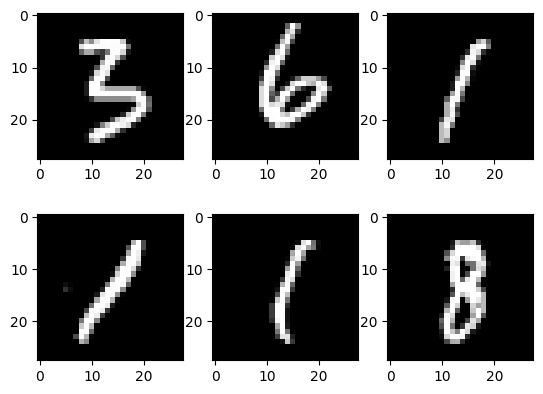

In [7]:
for i in range (6):
  plt.subplot(2,3,i+1)
  plt.imshow(samples[i][0], cmap='gray')

In [8]:
class Neural_Network(nn.Module):

  def __init__(self, input_size, hidden_size, num_classes):
    super(Neural_Network, self).__init__()
    self.l1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    return out


model = Neural_Network(input_size, hidden_size, num_classes)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
n_total_steps = len(train_loader)

for epoch in range (num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28*28)

    output = model(images)
    loss = criterion(output, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % 100 == 0:
      print (f'epoch:{epoch+1} / {num_epochs}, step {i+1} / {n_total_steps}, loss: {loss.item():.4f}')

epoch:1 / 2, step 100 / 600, loss: 1.1922
epoch:1 / 2, step 200 / 600, loss: 0.7192
epoch:1 / 2, step 300 / 600, loss: 0.4841
epoch:1 / 2, step 400 / 600, loss: 0.5147
epoch:1 / 2, step 500 / 600, loss: 0.3688
epoch:1 / 2, step 600 / 600, loss: 0.4878
epoch:2 / 2, step 100 / 600, loss: 0.3133
epoch:2 / 2, step 200 / 600, loss: 0.2849
epoch:2 / 2, step 300 / 600, loss: 0.2867
epoch:2 / 2, step 400 / 600, loss: 0.4160
epoch:2 / 2, step 500 / 600, loss: 0.3233
epoch:2 / 2, step 600 / 600, loss: 0.2424


In [11]:
with torch.no_grad():
  n_correct = 0
  n_samples = 0
  for images, labels in test_loader:
    images = images.reshape(-1, 28*28)

    outputs = model(images)

    _, predictions = torch.max(outputs, 1)
    n_samples += labels.shape[0]
    n_correct += (predictions ==  labels).sum().item()

  acc = 100.0 * n_correct / n_samples
  print(f'Accuracy = {acc}')

Accuracy = 91.52
